In [1]:
import pandas as pd
import numpy as np
import statsmodels.api as sm
from statsmodels.tsa.stattools import adfuller

def select_pairs(price_window, corr_threshold=0.9, top_n=3, coint_pvalue=0.05):
    """Phase 3's logic, packaged to run on any trailing window."""
    clean = price_window.drop(columns=[c for c in KNOWN_PEGGED if c in price_window.columns])
    corr_matrix = clean.corr()

    candidates = []
    for coin in corr_matrix.columns:
        top_matches = corr_matrix[coin].drop(coin).sort_values(ascending=False).head(top_n)
        for match, corr_value in top_matches.items():
            if corr_value >= corr_threshold:
                pair = tuple(sorted([coin, match]))
                candidates.append(pair)
    candidates = list(set(candidates))

    selected = []
    for a, b in candidates:
        combined = pd.concat([clean[a], clean[b]], axis=1).dropna()
        if len(combined) < 100:
            continue
        x = sm.add_constant(combined.iloc[:, 1])
        resid = sm.OLS(combined.iloc[:, 0], x).fit().resid
        p_value = adfuller(resid)[1]
        if p_value < coint_pvalue:
            selected.append((a, b))
    return selected

def compute_signals(price_a, price_b, window=90):
    rolling_cov = price_a.rolling(window).cov(price_b)
    rolling_var = price_b.rolling(window).var()
    beta = rolling_cov / rolling_var
    alpha = price_a.rolling(window).mean() - beta * price_b.rolling(window).mean()
    spread = price_a - (alpha + beta * price_b)
    z_score = (spread - spread.rolling(window).mean()) / spread.rolling(window).std()
    return pd.DataFrame({"beta": beta, "spread": spread, "z_score": z_score})

def generate_positions(z_score, entry=1.0, exit=0.5):
    position = pd.Series(0, index=z_score.index)
    pos = 0
    for i in range(len(z_score)):
        z = z_score.iloc[i]
        if pd.isna(z):
            position.iloc[i] = 0
            continue
        if pos == 0:
            if z > entry: pos = -1
            elif z < -entry: pos = 1
        else:
            if abs(z) < exit: pos = 0
        position.iloc[i] = pos
    return position

def compute_pair_returns(price_a, price_b, position, beta):
    ret_a = price_a.pct_change(fill_method=None)
    ret_b = price_b.pct_change(fill_method=None)
    return position.shift(1) * (ret_a - beta.shift(1) * ret_b)

def compute_pair_costs(position, cost_bps=0.0020):
    return position.diff().abs().fillna(0) * cost_bps

In [2]:
prices = pd.read_csv("../data/processed/prices.csv", index_col="date", parse_dates=True)
log_prices = np.log(prices)

# same pegged-asset exclusion as Phase 3
volatility = prices.pct_change(fill_method=None).std()
likely_pegged = volatility[volatility < 0.01].index
KNOWN_PEGGED = list(likely_pegged) + ["euro-coin", "societe-generale-forge-eurcv", "pax-gold", "tether-gold"]

In [3]:
daily_returns = prices.pct_change(fill_method=None)
extreme_day_counts = (daily_returns.abs() > 0.5).sum()

MAX_EXTREME_DAYS = 2
unreliable_coins = extreme_day_counts[extreme_day_counts > MAX_EXTREME_DAYS].index
print(f"Excluding {len(unreliable_coins)} coins with unreliable data: {list(unreliable_coins)}")

prices_clean = prices.drop(columns=[c for c in unreliable_coins if c in prices.columns])
log_prices_clean = np.log(prices_clean)

Excluding 13 coins with unreliable data: ['aerodrome-finance', 'apecoin', 'coti', 'global-dollar', 'htx-dao', 'jupiter-exchange-solana', 'meta-2-2', 'monad', 'openeden', 'peanut-the-squirrel', 'polyswarm', 'starknet', 'the-open-network']


In [4]:
SELECTION_WINDOW = 180
SIGNAL_WARMUP = 90
REBALANCE_FREQ = 90

start_idx = SELECTION_WINDOW + SIGNAL_WARMUP
rebalance_points = range(start_idx, len(log_prices_clean) - 1, REBALANCE_FREQ)

all_period_returns = []
all_period_costs = []
period_pair_counts = []

for t in rebalance_points:
    selection_window = log_prices_clean.iloc[t - SELECTION_WINDOW:t]
    trading_window_end = min(t + REBALANCE_FREQ, len(log_prices_clean))

    pairs = select_pairs(selection_window)
    period_pair_counts.append({"rebalance_day": t, "date": log_prices_clean.index[t], "n_pairs": len(pairs)})

    if len(pairs) == 0:
        continue

    period_returns = {}
    period_costs = {}
    for a, b in pairs:
        sig = compute_signals(log_prices_clean[a].iloc[:trading_window_end], log_prices_clean[b].iloc[:trading_window_end], window=SIGNAL_WARMUP)
        pos = generate_positions(sig["z_score"], entry=1.0, exit=0.5)

        pos_slice = pos.iloc[t:trading_window_end]
        ret = compute_pair_returns(prices_clean[a], prices_clean[b], pos, sig["beta"]).iloc[t:trading_window_end]
        cost = compute_pair_costs(pos).iloc[t:trading_window_end]

        period_returns[(a, b)] = ret
        period_costs[(a, b)] = cost

    all_period_returns.append(pd.DataFrame(period_returns).mean(axis=1))
    all_period_costs.append(pd.DataFrame(period_costs).mean(axis=1))

walk_forward_returns = pd.concat(all_period_returns)
walk_forward_costs = pd.concat(all_period_costs)
walk_forward_net = walk_forward_returns - walk_forward_costs

pd.DataFrame(period_pair_counts)

,rebalance_day,date,n_pairs
0,270,2025-05-24,160
1,360,2025-08-22,85
2,450,2025-11-20,103
3,540,2026-02-18,166
4,630,2026-05-19,172
5,720,2026-08-17,109


In [5]:
ann_return = walk_forward_net.mean() * 252
ann_vol = walk_forward_net.std() * np.sqrt(252)
sharpe = ann_return / ann_vol

print(f"Walk-forward annualized return: {ann_return:.2%}")
print(f"Walk-forward annualized vol:    {ann_vol:.2%}")
print(f"Walk-forward Sharpe:            {sharpe:.3f}")

walk_forward_net.describe()

Walk-forward annualized return: 5.37%
Walk-forward annualized vol:    9.31%
Walk-forward Sharpe:            0.577


count    461.000000
mean       0.000213
std        0.005867
min       -0.032675
25%       -0.002396
50%        0.000288
75%        0.003179
max        0.027224
dtype: float64

### Data quality check

Investigating an extreme single-day loss in the initial walk-forward run
traced back to a bad data point in `meta-2-2` (one day showing a price
~10x off from surrounding days, confirmed against a real crypto ticker,
not a stock-ticker collision). Broader scan found several other thinly-traded
coins with repeated extreme single-day moves (monad, jupiter-exchange-solana,
openeden), suggesting a systemic Yahoo data quality issue for low-volume
tokens rather than isolated events. Added a filter excluding coins with
more than 2 days of >50% single-day moves.

In [6]:
walk_forward_net.to_csv("../data/processed/walk_forward_net.csv")

In [7]:
import matplotlib.pyplot as plt

cumulative_returns = (1 + walk_forward_net).cumprod()
running_max = cumulative_returns.cummax()
drawdown = (cumulative_returns - running_max) / running_max

max_drawdown = drawdown.min()
print(f"Max drawdown: {max_drawdown:.2%}")

Max drawdown: -10.11%


In [8]:
def compute_max_drawdown_duration(cumulative_returns):
    running_max = cumulative_returns.cummax()
    is_underwater = cumulative_returns < running_max

    max_duration = 0
    current_duration = 0
    for underwater in is_underwater:
        if underwater:
            current_duration += 1
            max_duration = max(max_duration, current_duration)
        else:
            current_duration = 0
    return max_duration

max_dd_duration = compute_max_drawdown_duration(cumulative_returns)
print(f"Max drawdown duration: {max_dd_duration} trading days (~{max_dd_duration/21:.1f} months)")

Max drawdown duration: 136 trading days (~6.5 months)


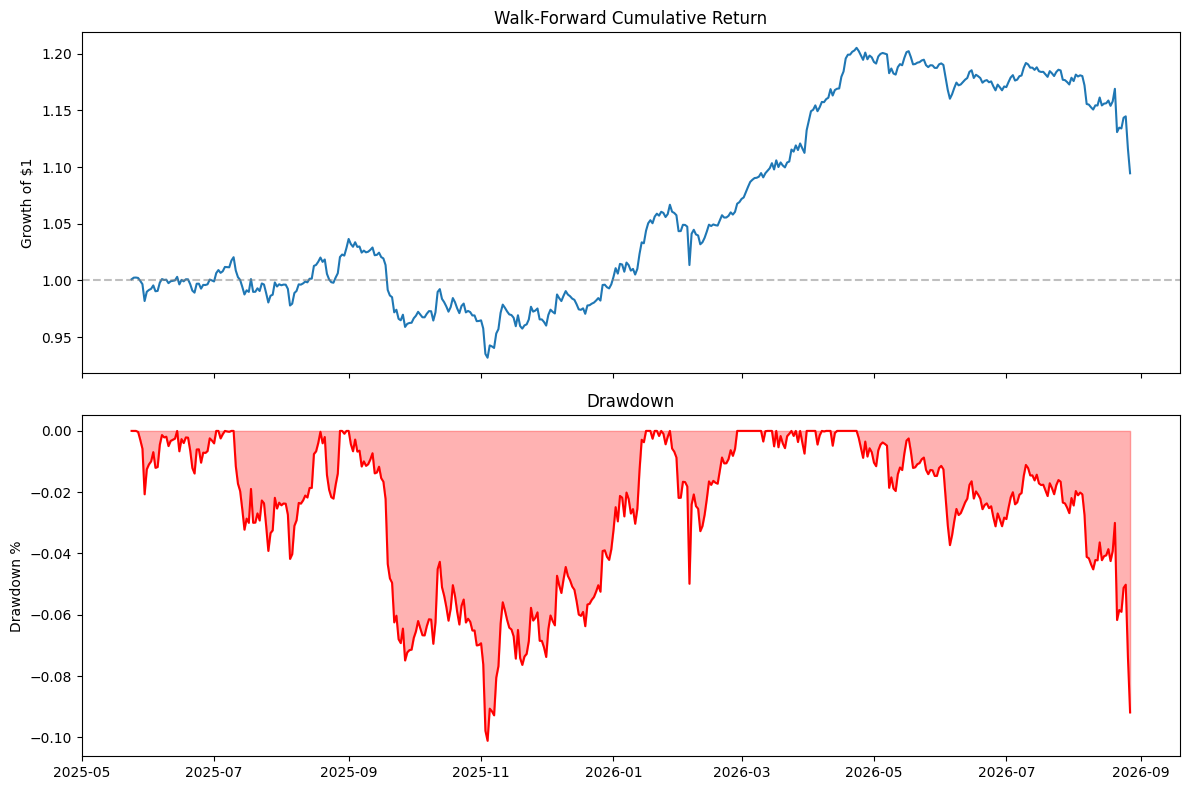

In [9]:
fig, axes = plt.subplots(2, 1, figsize=(12, 8), sharex=True)

axes[0].plot(cumulative_returns.index, cumulative_returns.values)
axes[0].set_title("Walk-Forward Cumulative Return")
axes[0].set_ylabel("Growth of $1")
axes[0].axhline(1, color="gray", linestyle="--", alpha=0.5)

axes[1].fill_between(drawdown.index, drawdown.values, 0, color="red", alpha=0.3)
axes[1].plot(drawdown.index, drawdown.values, color="red")
axes[1].set_title("Drawdown")
axes[1].set_ylabel("Drawdown %")

plt.tight_layout()
plt.savefig("../reports/tear_sheet.png", dpi=150)
plt.show()

In [10]:
tear_sheet = pd.Series({
    "Annualized Return": f"{ann_return:.2%}",
    "Annualized Volatility": f"{ann_vol:.2%}",
    "Sharpe Ratio": f"{sharpe:.3f}",
    "Max Drawdown": f"{max_drawdown:.2%}",
    "Max Drawdown Duration (days)": max_dd_duration,
    "Total Return (period)": f"{cumulative_returns.iloc[-1] - 1:.2%}",
})
tear_sheet

Annualized Return                 5.37%
Annualized Volatility             9.31%
Sharpe Ratio                      0.577
Max Drawdown                    -10.11%
Max Drawdown Duration (days)        136
Total Return (period)             9.46%
dtype: object

In [11]:
drawdown_start = drawdown[drawdown == 0].index[drawdown[drawdown == 0].index < drawdown.idxmin()][-1]
drawdown_trough = drawdown.idxmin()
print(f"Drawdown ran from {drawdown_start.date()} to trough at {drawdown_trough.date()}")

Drawdown ran from 2025-09-01 to trough at 2025-11-04


In [12]:
tear_sheet.to_csv("../reports/tear_sheet.csv")

In [13]:
btc_returns = prices_clean["bitcoin"].pct_change(fill_method=None)
btc_returns_aligned = btc_returns.loc[walk_forward_net.index]

btc_cumulative = (1 + btc_returns_aligned).cumprod()
strategy_cumulative = (1 + walk_forward_net).cumprod()

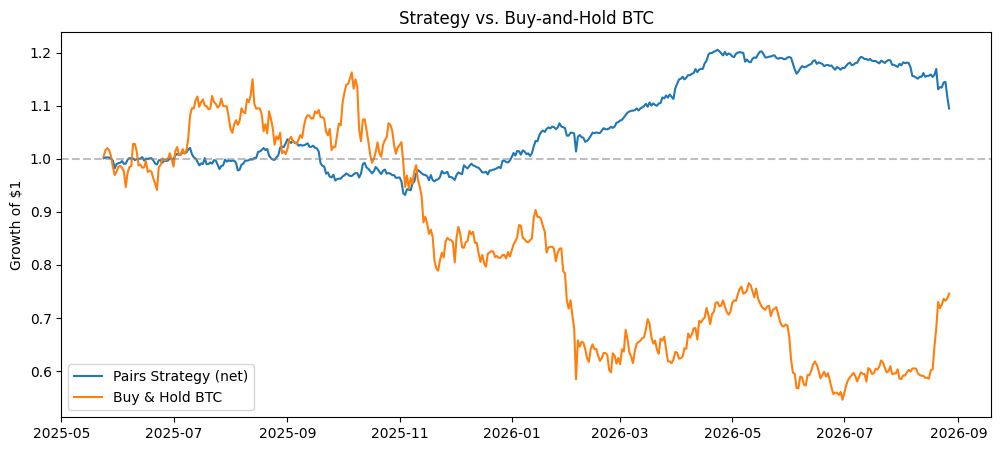

Strategy total return: 9.46%
BTC buy-and-hold total return: -25.41%


In [14]:
fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(strategy_cumulative.index, strategy_cumulative.values, label="Pairs Strategy (net)")
ax.plot(btc_cumulative.index, btc_cumulative.values, label="Buy & Hold BTC")
ax.axhline(1, color="gray", linestyle="--", alpha=0.5)
ax.set_title("Strategy vs. Buy-and-Hold BTC")
ax.set_ylabel("Growth of $1")
ax.legend()
plt.savefig("../reports/benchmark_comparison.png", dpi=150)
plt.show()

print(f"Strategy total return: {strategy_cumulative.iloc[-1] - 1:.2%}")
print(f"BTC buy-and-hold total return: {btc_cumulative.iloc[-1] - 1:.2%}")

In [15]:
import statsmodels.api as sm

x = sm.add_constant(btc_returns_aligned)
model = sm.OLS(walk_forward_net, x, missing="drop").fit()

beta_to_btc = model.params["bitcoin"]
alpha_daily = model.params["const"]
print(f"Beta to BTC:  {beta_to_btc:.3f}")
print(f"Daily alpha:  {alpha_daily:.5f}  (annualized: {alpha_daily*252:.2%})")
print(f"R-squared:    {model.rsquared:.3f}")

Beta to BTC:  0.077
Daily alpha:  0.00024  (annualized: 6.15%)
R-squared:    0.082


In [19]:
alpha_annualized = alpha_daily * 252
residual_vol_annualized = residual_returns.std() * np.sqrt(252)
information_ratio = alpha_annualized / residual_vol_annualized
print(f"Information ratio (purified): {information_ratio:.3f}")

Information ratio (purified): 0.689
